In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import and execute method for suppressing warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [2]:
flu_data=pd.read_csv("/Users/bhargavic/Downloads/FluNet WHO.csv")
flu_data.head()

,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHERRESPVIRUS,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV
0,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-02,2017,1,2017-01-01,...,NaN,NaN,NaN,NaN,AW,201701,201701,NaN,NaN,NaN
1,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-09,2017,2,2017-01-08,...,NaN,NaN,NaN,NaN,AW,201702,201702,NaN,NaN,NaN
2,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-16,2017,3,2017-01-15,...,NaN,NaN,NaN,NaN,AW,201703,201703,NaN,NaN,NaN
3,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-23,2017,4,2017-01-22,...,NaN,NaN,NaN,NaN,AW,201704,201704,NaN,NaN,NaN
4,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-30,2017,5,2017-01-29,...,NaN,NaN,NaN,NaN,AW,201705,201705,NaN,NaN,NaN


In [3]:
flu_data.head().T

,0,1,2,3,4
WHOREGION,AMR,AMR,AMR,AMR,AMR
FLUSEASON,YR,YR,YR,YR,YR
HEMISPHERE,NH,NH,NH,NH,NH
ITZ,FLU_CNT_AMC,FLU_CNT_AMC,FLU_CNT_AMC,FLU_CNT_AMC,FLU_CNT_AMC
COUNTRY_CODE,ABW,ABW,ABW,ABW,ABW
COUNTRY_AREA_TERRITORY,Aruba,Aruba,Aruba,Aruba,Aruba
ISO_WEEKSTARTDATE,2017-01-02,2017-01-09,2017-01-16,2017-01-23,2017-01-30
ISO_YEAR,2017,2017,2017,2017,2017
ISO_WEEK,1,2,3,4,5
MMWR_WEEKSTARTDATE,2017-01-01,2017-01-08,2017-01-15,2017-01-22,2017-01-29


In [4]:
flu_data.shape


(182714, 53)

In [5]:
flu_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182714 entries, 0 to 182713
Data columns (total 53 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   WHOREGION                182714 non-null  object 
 1   FLUSEASON                182714 non-null  object 
 2   HEMISPHERE               182714 non-null  object 
 3   ITZ                      182714 non-null  object 
 4   COUNTRY_CODE             182714 non-null  object 
 5   COUNTRY_AREA_TERRITORY   182714 non-null  object 
 6   ISO_WEEKSTARTDATE        182714 non-null  object 
 7   ISO_YEAR                 182714 non-null  int64  
 8   ISO_WEEK                 182714 non-null  int64  
 9   MMWR_WEEKSTARTDATE       182714 non-null  object 
 10  MMWR_YEAR                182714 non-null  int64  
 11  MMWR_WEEK                182714 non-null  int64  
 12  ORIGIN_SOURCE            182714 non-null  object 
 13  SPEC_PROCESSED_NB        169977 non-null  float64
 14  SPEC

In [6]:
flu_data.isnull().sum()

WHOREGION                       0
FLUSEASON                       0
HEMISPHERE                      0
ITZ                             0
COUNTRY_CODE                    0
COUNTRY_AREA_TERRITORY          0
ISO_WEEKSTARTDATE               0
ISO_YEAR                        0
ISO_WEEK                        0
MMWR_WEEKSTARTDATE              0
MMWR_YEAR                       0
MMWR_WEEK                       0
ORIGIN_SOURCE                   0
SPEC_PROCESSED_NB           12737
SPEC_RECEIVED_NB           119093
AH1N12009                   47360
AH1                         81675
AH3                         30358
AH5                        123290
AH7N9                      158505
ANOTSUBTYPED                35808
ANOTSUBTYPABLE             164859
AOTHER_SUBTYPE             134839
AOTHER_SUBTYPE_DETAILS     175205
INF_A                       23581
BVIC_2DEL                  172425
BVIC_3DEL                  173590
BVIC_NODEL                  60977
BVIC_DELUNK                173190
BYAM          

In [7]:
flu_data['INF_ALL'].isna().mean()

np.float64(0.44276300666615587)

In [8]:
flu_data[flu_data['COUNTRY_CODE']=='USA']['INF_ALL'].isna().mean()

np.float64(0.019699326075686883)

In [9]:
flu_data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
182709    False
182710    False
182711    False
182712    False
182713    False
Length: 182714, dtype: bool

In [10]:
flu_data.duplicated().sum()

np.int64(0)

In [11]:
flu_data['ISO_WEEKSTARTDATE'] = pd.to_datetime(flu_data['ISO_WEEKSTARTDATE'])

In [12]:
flu_data.duplicated(subset=['COUNTRY_CODE', 'ISO_WEEKSTARTDATE']).sum()

np.int64(39073)

In [13]:
flu_data['ISO_WEEKSTARTDATE'].isna().sum()

np.int64(0)

In [14]:
cols_needed = ['COUNTRY_CODE', 'ISO_WEEKSTARTDATE', 'INF_ALL']
flu_data = flu_data[cols_needed]
flu_data.head()

,COUNTRY_CODE,ISO_WEEKSTARTDATE,INF_ALL
0,ABW,2017-01-02,11.0
1,ABW,2017-01-09,NaN
2,ABW,2017-01-16,3.0
3,ABW,2017-01-23,1.0
4,ABW,2017-01-30,NaN


In [15]:
flu_data = flu_data.groupby(['COUNTRY_CODE', 'ISO_WEEKSTARTDATE']).agg({
    'INF_ALL': 'sum'
}).reset_index()

In [16]:
flu_data.head(10)

,COUNTRY_CODE,ISO_WEEKSTARTDATE,INF_ALL
0,ABW,2017-01-02,11.0
1,ABW,2017-01-09,0.0
2,ABW,2017-01-16,3.0
3,ABW,2017-01-23,1.0
4,ABW,2017-01-30,0.0
5,ABW,2017-02-06,1.0
6,ABW,2017-02-13,1.0
7,ABW,2017-02-20,2.0
8,ABW,2017-02-27,2.0
9,ABW,2017-03-06,0.0


In [17]:
flu_data.tail(10)

,COUNTRY_CODE,ISO_WEEKSTARTDATE,INF_ALL
143631,ZWE,2025-12-29,0.0
143632,ZWE,2026-01-05,0.0
143633,ZWE,2026-01-12,0.0
143634,ZWE,2026-01-19,0.0
143635,ZWE,2026-01-26,0.0
143636,ZWE,2026-02-02,0.0
143637,ZWE,2026-02-09,0.0
143638,ZWE,2026-02-16,0.0
143639,ZWE,2026-02-23,0.0
143640,ZWE,2026-03-02,0.0


In [18]:
flu_data.nunique()

COUNTRY_CODE          189
ISO_WEEKSTARTDATE    1604
INF_ALL              2519
dtype: int64

In [19]:
flu_data.columns

Index(['COUNTRY_CODE', 'ISO_WEEKSTARTDATE', 'INF_ALL'], dtype='object')

In [20]:
flu_data.dtypes

COUNTRY_CODE                 object
ISO_WEEKSTARTDATE    datetime64[ns]
INF_ALL                     float64
dtype: object

In [21]:
flu_data['COUNTRY_CODE'].unique()

array(['ABW', 'AFG', 'AGO', 'AIA', 'ALB', 'ARE', 'ARG', 'ARM', 'ATG',
       'AUS', 'AUT', 'AZE', 'BEL', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS',
       'BIH', 'BLM', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'BRN',
       'BTN', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD',
       'COG', 'COL', 'CRI', 'CUB', 'CYM', 'CYP', 'CZE', 'DEU', 'DMA',
       'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'EST', 'ETH', 'FIN',
       'FJI', 'FRA', 'GAB', 'GEO', 'GHA', 'GIN', 'GLP', 'GRC', 'GRD',
       'GTM', 'GUF', 'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN',
       'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR',
       'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KNA', 'KOR', 'KWT', 'LAO',
       'LBN', 'LBR', 'LBY', 'LCA', 'LIE', 'LKA', 'LSO', 'LTU', 'LUX',
       'LVA', 'MAF', 'MAR', 'MDA', 'MDG', 'MDV', 'MEX', 'MKD', 'MLI',
       'MLT', 'MMR', 'MNE', 'MNG', 'MOZ', 'MRT', 'MSR', 'MTQ', 'MUS',
       'MYS', 'NAM', 'NCL', 'NER', 'NGA', 'NIC', 'NLD', 'NOR', 'NPL',
       'NZL', 'OMN',

In [22]:
flu_data.head()

,COUNTRY_CODE,ISO_WEEKSTARTDATE,INF_ALL
0,ABW,2017-01-02,11.0
1,ABW,2017-01-09,0.0
2,ABW,2017-01-16,3.0
3,ABW,2017-01-23,1.0
4,ABW,2017-01-30,0.0


In [23]:
df_usa=flu_data[flu_data['COUNTRY_CODE'] == 'USA']

In [24]:
df_usa = df_usa.groupby('ISO_WEEKSTARTDATE')['INF_ALL'].sum().reset_index()

Remaining duplicates in USA index: 0


<Axes: title={'center': 'Cleaned USA Flu Signal (Aggregate)'}, xlabel='ISO_WEEKSTARTDATE'>

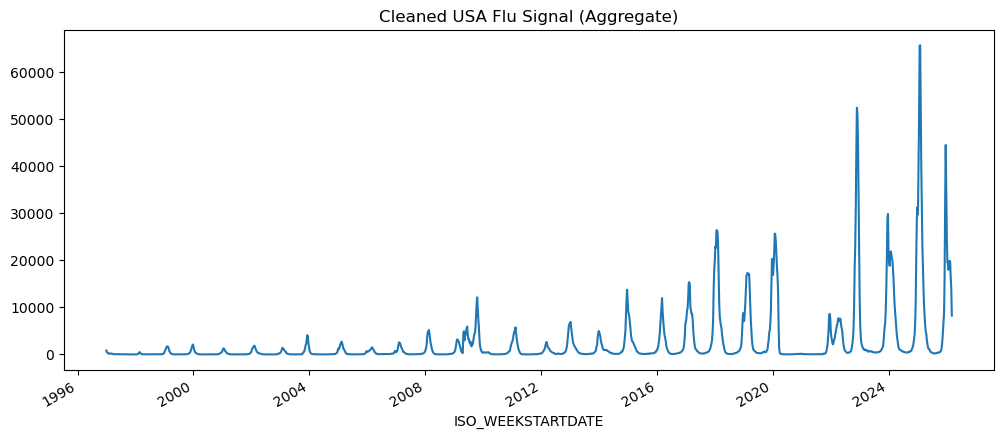

In [25]:
# 1. Filter for USA after the global sum
df_usa = flu_data[flu_data['COUNTRY_CODE'] == 'USA'].copy()
df_usa['ISO_WEEKSTARTDATE'] = pd.to_datetime(df_usa['ISO_WEEKSTARTDATE'])
df_usa.set_index('ISO_WEEKSTARTDATE', inplace=True)
df_usa.sort_index(inplace=True)

# 2. Check for Duplicates AGAIN (Should be 0 now)
print(f"Remaining duplicates in USA index: {df_usa.index.duplicated().sum()}")

# 3. The Final Plot (Should be ONE clean line now)
df_usa['INF_ALL'].plot(figsize=(12,5), title="Cleaned USA Flu Signal (Aggregate)")


In [26]:
df_usa = df_usa.rename(columns={'INF_ALL': 'flu_index'})

In [27]:
df_usa.head()

,COUNTRY_CODE,flu_index
ISO_WEEKSTARTDATE,,
1996-12-30,USA,831.0
1997-01-06,USA,457.0
1997-01-13,USA,328.0
1997-01-20,USA,222.0
1997-01-27,USA,218.0


In [28]:
# 1. Calculate how many weeks SHOULD exist vs how many DO exist
expected_weeks = (df_usa.index.max() - df_usa.index.min()).days / 7
actual_weeks = len(df_usa)

print(f"Data spans from {df_usa.index.min().year} to {df_usa.index.max().year}")
print(f"Expected Weeks: {int(expected_weeks)}")
print(f"Actual Weeks in Data: {actual_weeks}")
print(f"Missing Weeks: {int(expected_weeks - actual_weeks)}")


Data spans from 1996 to 2026
Expected Weeks: 1523
Actual Weeks in Data: 1384
Missing Weeks: 139


df_usa = df_usa.asfreq('W') #To ensure that time series is in weeks

In [29]:
# 1. Force the weekly frequency to reveal the NaNs
df_usa_gap = df_usa.asfreq('W')

# 2. Find the dates of the missing weeks
missing_dates = df_usa_gap[df_usa_gap['flu_index'].isna()].index
print(f"First 5 missing weeks: \n{missing_dates[:5]}")
print(f"Last 5 missing weeks: \n{missing_dates[-5:]}")


First 5 missing weeks: 
DatetimeIndex(['1997-01-05', '1997-01-12', '1997-01-19', '1997-01-26',
               '1997-02-02'],
              dtype='datetime64[ns]', name='ISO_WEEKSTARTDATE', freq='W-SUN')
Last 5 missing weeks: 
DatetimeIndex(['2026-02-08', '2026-02-15', '2026-02-22', '2026-03-01',
               '2026-03-08'],
              dtype='datetime64[ns]', name='ISO_WEEKSTARTDATE', freq='W-SUN')


In [30]:
# Focus on the 'Modern Era' of high-fidelity reporting
df_final = df_usa_gap.loc['2015-01-01':].copy()

# Fill the small remaining gaps in this window
df_final['flu_index'] = df_final['flu_index'].interpolate(method='linear')

print(f"Remaining NaNs in the Modern Window: {df_final['flu_index'].isna().sum()}")


Remaining NaNs in the Modern Window: 584


In [31]:
# 1. Find the last week that actually has a value > 0
last_real_week = df_usa[df_usa['flu_index'] > 0].index.max()
print(f"The last reliable data point is: {last_real_week}")

# 2. Re-filter your 'Modern Window' based on that reality
df_final = df_usa.loc['2015-01-01':last_real_week].asfreq('W')

# 3. Now check NaNs again
print(f"Remaining NaNs in the ACTUAL reported window: {df_final['flu_index'].isna().sum()}")


The last reliable data point is: 2026-03-09 00:00:00
Remaining NaNs in the ACTUAL reported window: 583


In [32]:
import pandas as pd
import numpy as np

# 1. Force the flu_index column to be numeric
# 'coerce' turns any non-numeric junk into NaN so it doesn't crash
df_usa['flu_index'] = pd.to_numeric(df_usa['flu_index'], errors='coerce')

# 2. Now run the "Real Data Count" audit safely
modern_window = df_usa.loc['2015-01-01':]
real_data_count = (modern_window['flu_index'] > 0).sum()

print(f"Total weeks with actual flu cases since 2015: {real_data_count}")
print(f"Total weeks in the 2015-2026 window: {len(modern_window)}")


Total weeks with actual flu cases since 2015: 584
Total weeks in the 2015-2026 window: 584


In [33]:
df_usa.isna().sum()

COUNTRY_CODE    0
flu_index       0
dtype: int64

print(f"Data Starts: {df_usa.index.min()}")
print(f"Data Ends: {df_usa.index.max()}")
print(f"Total Rows: {len(df_usa)}")


In [34]:
df_usa['flu_index'] = df_usa['flu_index'].rolling(3, min_periods=1).mean()
df_usa['flu_lag_2'] = df_usa['flu_index'].shift(2)
df_usa = df_usa.dropna()

df_usa['flu_index'] = df_usa['flu_index'].rolling(3).mean() # Rolling mean to smooth out values and reduce noise

df_usa['flu_lag_2'] = df_usa['flu_index'].shift(2) # lag is added bcz flu symptoms show up after 14 days i.e 2 weeks

In [35]:
df_usa.head()

,COUNTRY_CODE,flu_index,flu_lag_2
ISO_WEEKSTARTDATE,,,
1997-01-13,USA,538.666667,831.000000
1997-01-20,USA,335.666667,644.000000
1997-01-27,USA,256.000000,538.666667
1997-02-03,USA,204.666667,335.666667
1997-02-10,USA,170.000000,256.000000


In [36]:

df_usa.tail()

,COUNTRY_CODE,flu_index,flu_lag_2
ISO_WEEKSTARTDATE,,,
2026-02-09,USA,19207.666667,18951.333333
2026-02-16,USA,19793.333333,19001.666667
2026-02-23,USA,18633.666667,19207.666667
2026-03-02,USA,16726.333333,19793.333333
2026-03-09,USA,12897.333333,18633.666667


In [37]:
df_usa = df_usa.loc['2015-01-01':]

<Axes: xlabel='ISO_WEEKSTARTDATE'>

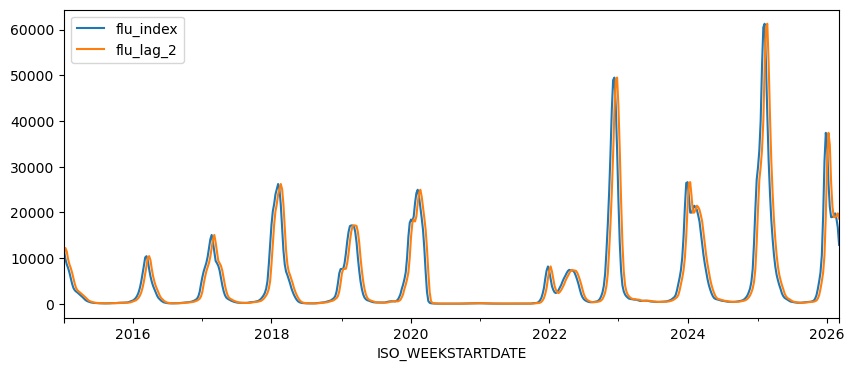

In [38]:
df_usa.plot(figsize=(10,4))

In [39]:
plt.savefig('flu_signal.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'Leading Indicator: 2-Week Lag (Supply Chain Lead Time)')

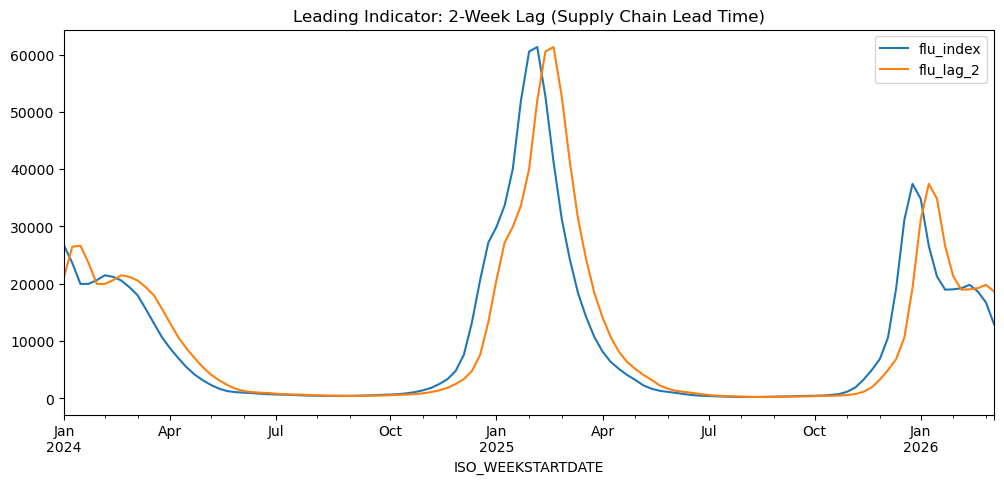

In [40]:
# Zoom in on the last 2 years so the 2-week gap is visible to the eye
df_usa.loc['2024-01-01':][['flu_index', 'flu_lag_2']].plot(figsize=(12,5))
plt.title("Leading Indicator: 2-Week Lag (Supply Chain Lead Time)")


In [41]:
plt.savefig('Leading_indicator:2 week lag(Supply chain Lead Time).png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [42]:
sales_wk=pd.read_csv("/Users/bhargavic/Downloads/Sales /salesweekly.csv")
sales_wk

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,1/5/2014,14.00,11.670,21.30,185.950,41.0,0.0,32.000000,7.00
1,1/12/2014,29.33,12.680,37.90,190.700,88.0,5.0,21.000000,7.20
2,1/19/2014,30.67,26.340,45.90,218.400,80.0,8.0,29.000000,12.00
3,1/26/2014,34.00,32.370,31.50,179.600,80.0,8.0,23.000000,10.00
4,2/2/2014,31.02,23.350,20.70,159.880,84.0,12.0,29.000000,12.00
...,...,...,...,...,...,...,...,...,...
297,9/15/2019,35.51,30.977,19.65,178.375,67.2,5.0,30.000000,30.50
298,9/22/2019,46.84,25.396,24.40,248.250,31.2,3.0,26.000000,21.00
299,9/29/2019,34.01,22.498,26.60,336.700,61.2,1.0,40.416667,23.10
300,10/6/2019,38.70,32.502,19.25,249.450,69.0,5.0,30.000000,12.13


In [43]:
sales_wk.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06'],
      dtype='object')

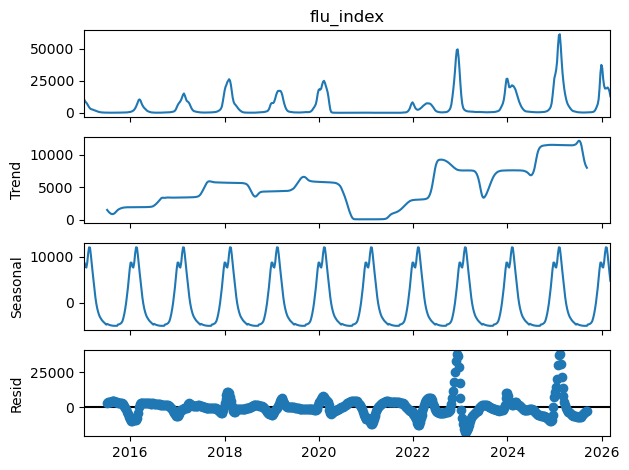

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Run decomposition on your clean 2015-2026 window
result = seasonal_decompose(df_usa['flu_index'], model='additive', period=52)
result.plot()
plt.show()


In [45]:
sales_wk.shape

(302, 9)

In [46]:
sales_wk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   datum   302 non-null    object 
 1   M01AB   302 non-null    float64
 2   M01AE   302 non-null    float64
 3   N02BA   302 non-null    float64
 4   N02BE   302 non-null    float64
 5   N05B    302 non-null    float64
 6   N05C    302 non-null    float64
 7   R03     302 non-null    float64
 8   R06     302 non-null    float64
dtypes: float64(8), object(1)
memory usage: 21.4+ KB


In [47]:
sales_wk.isnull().sum()

datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64

In [48]:
sales_wk.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
297    False
298    False
299    False
300    False
301    False
Length: 302, dtype: bool

In [49]:
sales_wk['date'] = pd.to_datetime(sales_wk['datum'], errors='coerce')

In [50]:
sales_wk = sales_wk.set_index('datum').sort_index()

In [51]:
sales_wk.head(10)

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,date
datum,,,,,,,,,
1/1/2017,49.203750,42.705250,31.529167,546.899000,53.75,6.875000,55.250000,4.625000,2017-01-01
1/10/2016,41.650000,25.136000,41.300000,342.200000,48.00,4.000000,35.000000,9.000000,2016-01-10
1/11/2015,19.340000,37.311000,32.900000,234.400000,98.00,7.000000,39.000000,10.000000,2015-01-11
1/12/2014,29.330000,12.680000,37.900000,190.700000,88.00,5.000000,21.000000,7.200000,2014-01-12
1/13/2019,35.660000,28.404000,20.200000,354.800000,79.20,6.000000,50.000000,6.000000,2019-01-13
1/14/2018,34.480000,30.345000,28.100000,255.525000,52.00,6.000000,44.000000,6.000000,2018-01-14
1/15/2017,48.745833,34.275417,60.125000,368.479167,120.00,5.416667,31.666667,12.166667,2017-01-15
1/17/2016,51.670000,27.211000,50.500000,365.250000,82.00,0.000000,21.000000,12.000000,2016-01-17
1/18/2015,39.350000,30.350000,38.800000,231.450000,115.00,4.000000,32.000000,9.000000,2015-01-18


In [52]:
sales_wk = sales_wk.set_index('date')


In [53]:
sales_wk = sales_wk.sort_index()

In [54]:
# keep only needed columns
df_sales = sales_wk[['R03', 'R06', 'N02BE']]

# rename
df_sales = df_sales.rename(columns={
    'R03': 'R03_sales',
    'R06': 'R06_sales',
    'N02BE': 'N02BE_sales'
})

In [55]:
df_sales = df_sales.loc['2015-01-01':]

In [56]:
df_sales = df_sales.interpolate(method='linear')


In [57]:
df_sales['resp_index'] = df_sales['R03_sales'] + df_sales['R06_sales']

In [58]:
df_sales.index = df_sales.index.to_series().dt.to_period('W').dt.to_timestamp()
df_usa.index   = df_usa.index.to_series().dt.to_period('W').dt.to_timestamp()

In [59]:
df_sales = df_sales.sort_index()
df_usa   = df_usa.sort_index()

In [60]:
df_combined = df_sales.join(df_usa[['flu_index','flu_lag_2']], how='inner')

In [61]:
pip install pmdarima


Note: you may need to restart the kernel to use updated packages.


In [62]:
df_combined = df_combined.dropna()

In [63]:
df_combined.shape

(249, 6)

In [64]:
df_combined.head()

,R03_sales,R06_sales,N02BE_sales,resp_index,flu_index,flu_lag_2
2015-01-05,39.0,10.0,234.40,49.0,11463.666667,11131.000000
2015-01-12,32.0,9.0,231.45,41.0,9763.000000,12205.666667
2015-01-19,58.0,8.0,246.55,66.0,8622.000000,11463.666667
2015-01-26,40.0,9.0,199.30,49.0,7836.000000,9763.000000
2015-02-02,36.0,11.0,195.25,47.0,6828.333333,8622.000000


In [65]:
df_combined[['flu_index','flu_lag_2']].head(10)

,flu_index,flu_lag_2
2015-01-05,11463.666667,11131.000000
2015-01-12,9763.000000,12205.666667
2015-01-19,8622.000000,11463.666667
2015-01-26,7836.000000,9763.000000
2015-02-02,6828.333333,8622.000000
2015-02-09,5565.666667,7836.000000
2015-02-16,4395.333333,6828.333333
2015-02-23,3467.666667,5565.666667
2015-03-02,2965.333333,4395.333333
2015-03-09,2683.666667,3467.666667


<Axes: >

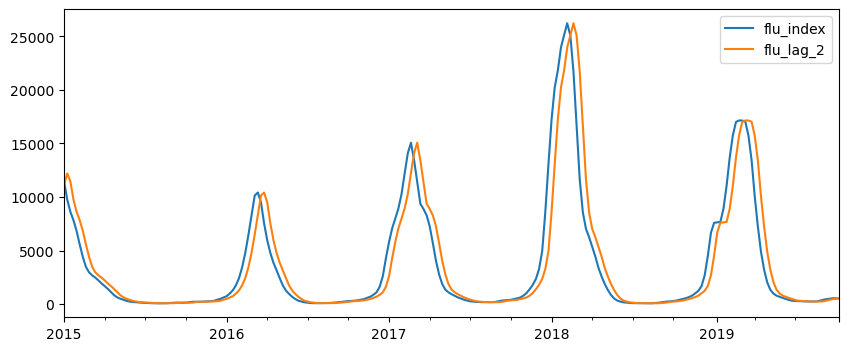

In [66]:
df_combined[['flu_index','flu_lag_2']].plot(figsize=(10,4))

In [67]:
df_combined.corr()

,R03_sales,R06_sales,N02BE_sales,resp_index,flu_index,flu_lag_2
R03_sales,1.000000,-0.151913,0.414735,0.879969,0.274166,0.262566
R06_sales,-0.151913,1.000000,-0.471042,0.335840,-0.138247,0.006731
N02BE_sales,0.414735,-0.471042,1.000000,0.168846,0.226641,0.115942
resp_index,0.879969,0.335840,0.168846,1.000000,0.194831,0.253455
flu_index,0.274166,-0.138247,0.226641,0.194831,1.000000,0.925357
flu_lag_2,0.262566,0.006731,0.115942,0.253455,0.925357,1.000000


In [68]:
# 1. The "Business Truth" Correlation
sales_flu_corr = df_combined['R03_sales'].corr(df_combined['flu_index'])
sales_lag_corr = df_combined['R03_sales'].corr(df_combined['flu_lag_2'])

print(f"--- Demand Sensing Proof ---")
print(f"Sales vs. Current Flu (Lag 0): {sales_flu_corr:.3f}")
print(f"Sales vs. Engineered Lead Time (Lag 2): {sales_lag_corr:.3f}")


--- Demand Sensing Proof ---
Sales vs. Current Flu (Lag 0): 0.274
Sales vs. Engineered Lead Time (Lag 2): 0.263


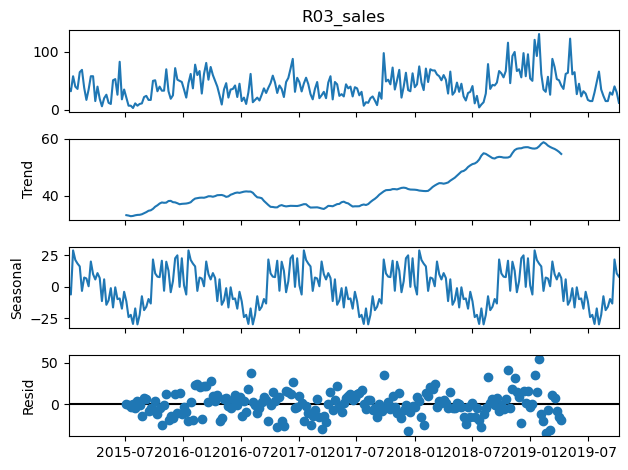

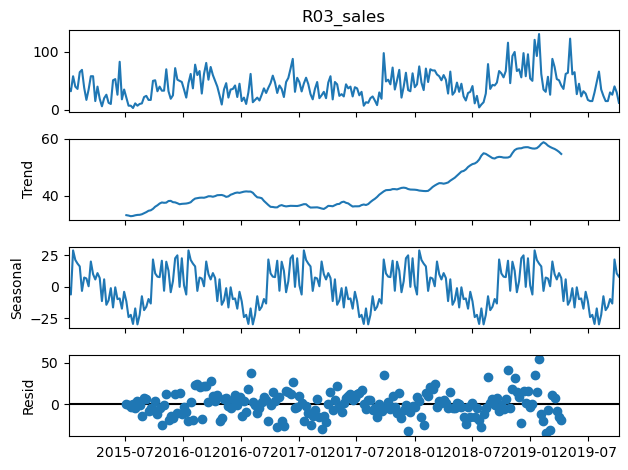

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_combined['R03_sales'], model='additive', period=52)
decomp.plot()

In [70]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_combined['R03_sales'])
print("p-value:", result[1])

p-value: 0.013805843181299318


In [71]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


from pmdarima import auto_arima

# We train on the RAW sales but tell the model to use d=1, D=1
# We pass the RAW flu_index as the exogenous 'X' variable
model = auto_arima(df_combined['R03_sales'], 
                   exogenous=df_combined[['flu_index']],
                   seasonal=True, m=52, 
                   d=1, D=1, 
                   trace=True, 
                   error_action='ignore', 
                   suppress_warnings=True)

print(model.summary())


# 1. Get the 'fitted' values (what the model predicted for the past)
fitted_values = model.predict_in_sample()

# 2. Calculate MAPE (Mean Absolute Percentage Error)
import numpy as np
actuals = df_combined['R03_sales']
mape = np.mean(np.abs((actuals - fitted_values) / actuals)) * 100

print(f"--- Model Accuracy Audit ---")
print(f"Final MAPE: {mape:.2f}%")
print(f"Accuracy Score: {100 - mape:.2f}%")


In [73]:
train_size = int(len(df_combined) * 0.8)

train = df_combined.iloc[:train_size]
test  = df_combined.iloc[train_size:]

In [74]:
model = auto_arima(
    train['R03_sales'],
    exogenous=train[['flu_index']],
    seasonal=True, m=52,
    d=1, D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[52]             : AIC=1307.227, Time=21.99 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=1393.204, Time=0.12 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=1336.760, Time=2.49 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=inf, Time=9.51 sec
 ARIMA(2,1,2)(0,1,1)[52]             : AIC=inf, Time=26.36 sec
 ARIMA(2,1,2)(1,1,0)[52]             : AIC=1305.290, Time=23.54 sec
 ARIMA(2,1,2)(0,1,0)[52]             : AIC=inf, Time=2.76 sec
 ARIMA(2,1,2)(2,1,0)[52]             : AIC=1307.227, Time=38.10 sec
 ARIMA(2,1,2)(2,1,1)[52]             : AIC=1309.226, Time=35.24 sec
 ARIMA(1,1,2)(1,1,0)[52]             : AIC=inf, Time=12.33 sec
 ARIMA(2,1,1)(1,1,0)[52]             : AIC=1304.312, Time=6.39 sec
 ARIMA(2,1,1)(0,1,0)[52]             : AIC=1334.261, Time=0.99 sec
 ARIMA(2,1,1)(2,1,0)[52]             : AIC=1306.250, Time=14.28 sec
 ARIMA(2,1,1)(1,1,1)[52]             : AIC=1306.250, Time=9.66 sec
 ARIMA(2,1,1)(0,1,1)[52]        

In [75]:
forecast = model.predict(
    n_periods=len(test),
    exogenous=test[['flu_index']]
)

In [76]:
import numpy as np

actuals = test['R03_sales']

mape = np.mean(np.abs((actuals - forecast) / actuals)) * 100

print(f"Test MAPE: {mape:.2f}%")

Test MAPE: 61.24%


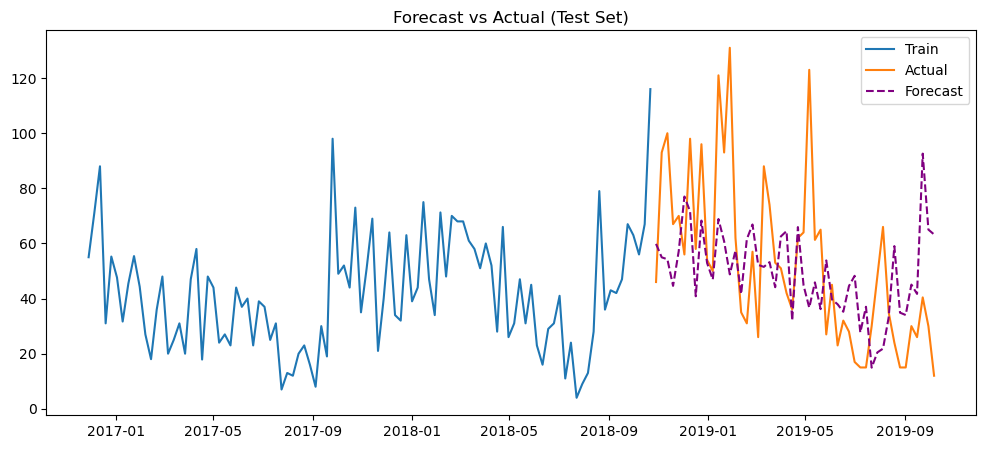

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(train.index[-100:], train['R03_sales'][-100:], label='Train')
plt.plot(test.index, test['R03_sales'], label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='--', color='purple')

plt.legend()
plt.title("Forecast vs Actual (Test Set)")
plt.show()

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define variables
y = df_combined['R03_sales']
X = df_combined[['flu_index']]

# Model
model = SARIMAX(
    y,
    exog=X,
    order=(1,0,1),              # basic ARIMA
    seasonal_order=(1,0,1,52)   # yearly seasonality
)

results = model.fit(disp=False)

print(results.summary())

In [78]:
# Run this in Jupyter to get your file ready
df_combined.to_csv('pharma_demand_sensing_gold.csv')
